# Trabajo Práctico 1 — Visión por Computadora

**Parte 1:** 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


**1.1: Implementacion del algoritmo White Patch**

In [6]:
def white_patch(img_bgr: np.ndarray, percentile: float = 100.0) -> np.ndarray:
    """
    Aplica el algoritmo White Patch a una imagen BGR de OpenCV.

    Parámetros
    ----------
    img_bgr    : np.ndarray uint8, shape (H, W, 3), formato BGR de OpenCV
    percentile : float  — 100 = máximo absoluto (White Patch clásico)
                          99  = variante robusta
    Retorna
    -------
    corrected : np.ndarray uint8, shape (H, W, 3)
    """
    img_f = img_bgr.astype(np.float32) # conviento la imagen de unit8 a float para poder dividir sin perder precision
    result = np.empty_like(img_f) #array vacio

    for ch in range(3):  # B=0, G=1, R=2
        max_val = np.percentile(img_f[:, :, ch], percentile) # toma el percentil indicado
        if max_val > 0:
            result[:, :, ch] = img_f[:, :, ch] / max_val * 255.0 #divido por ese maximo y escalo a 255, asi el valor maximo pasa a ser 255
        else:
            result[:, :, ch] = img_f[:, :, ch]

    return np.clip(result, 0, 255).astype(np.uint8)

**1.2: Carga de imágenes de la carpeta `white_patch`**

In [7]:
DIR_WP = Path('./white_patch')
images_wp = {}

if not DIR_WP.exists():
    raise FileNotFoundError('No se encontró la carpeta white_patch/')

for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
    for p in sorted(DIR_WP.glob(ext)):
        img = cv2.imread(str(p))
        if img is not None:
            images_wp[p.stem] = img

if not images_wp:
    raise ValueError('La carpeta white_patch/ existe pero no tiene imágenes (.png, .jpg, .jpeg, .bmp)')

print(f'Imágenes cargadas: {len(images_wp)}')
for k, v in images_wp.items():
    print(f'  {k}: {v.shape}')

Imágenes cargadas: 8
  test_blue: (100, 278, 3)
  test_green: (100, 278, 3)
  test_red: (99, 276, 3)
  wp_green: (571, 363, 3)
  wp_red: (813, 481, 3)
  wp_blue: (1600, 1200, 3)
  wp_green2: (1600, 1200, 3)
  wp_red2: (1600, 1200, 3)


**1.2: Mostrar resultados**


Imagen: test_blue
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       200.0         1.275x       180.0         1.417x
Verde (G)      138.0         1.848x       122.0         2.090x
Rojo (R)       165.0         1.545x       153.0         1.667x


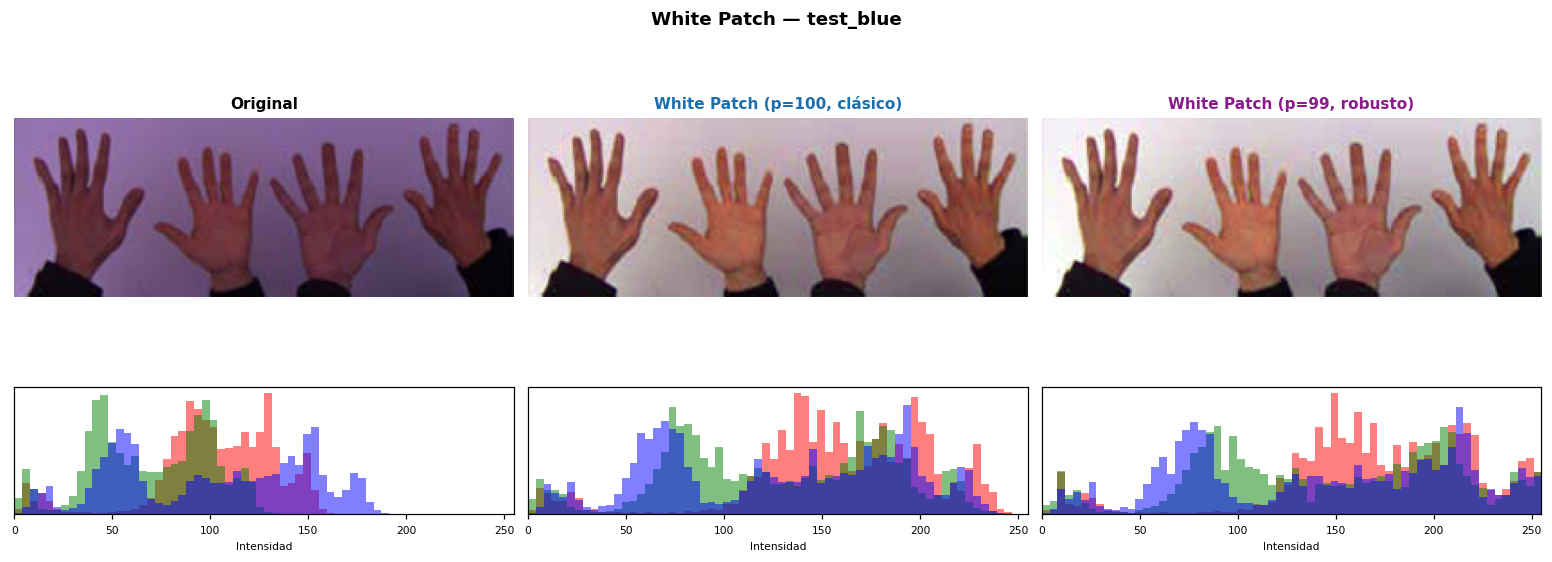


Imagen: test_green
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       171.0         1.491x       150.0         1.700x
Verde (G)      250.0         1.020x       230.0         1.109x
Rojo (R)       210.0         1.214x       193.0         1.321x


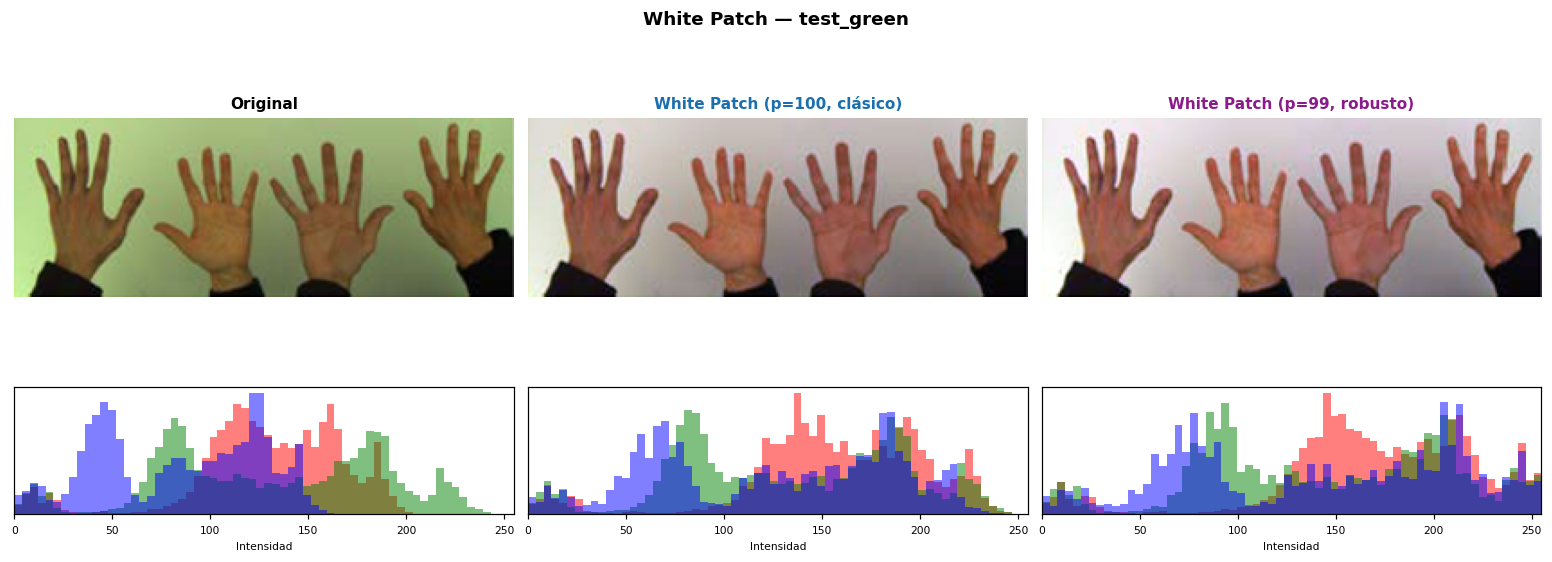


Imagen: test_red
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       175.0         1.457x       163.0         1.564x
Verde (G)      157.0         1.624x       143.0         1.783x
Rojo (R)       247.0         1.032x       230.0         1.109x


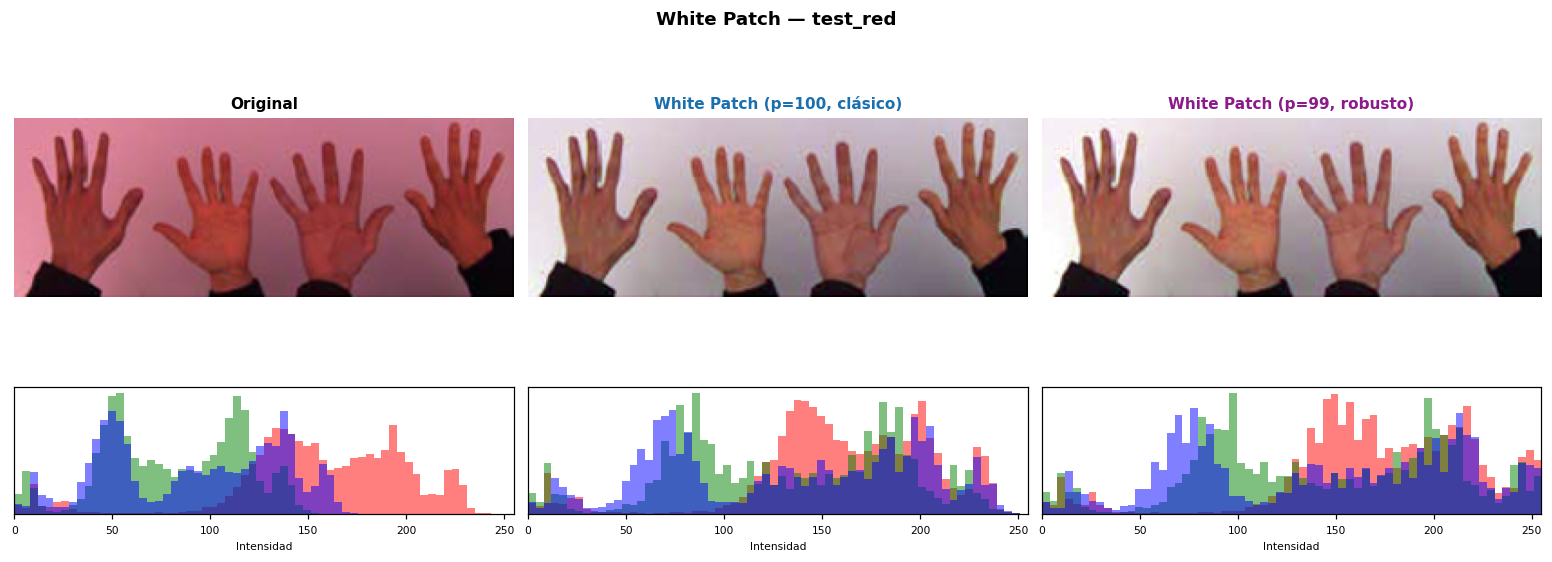


Imagen: wp_green
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       155.0         1.645x       120.0         2.125x
Verde (G)      252.0         1.012x       244.0         1.045x
Rojo (R)       126.0         2.024x        88.0         2.898x


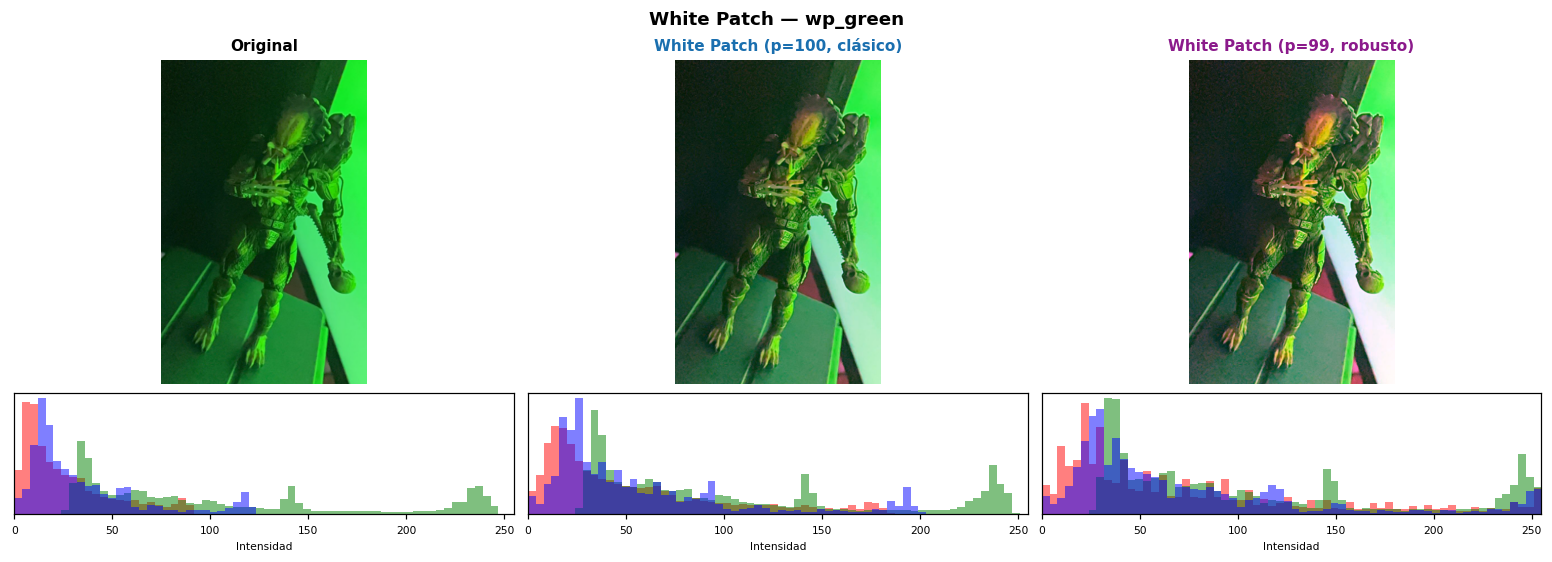


Imagen: wp_red
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       122.0         2.090x       102.0         2.500x
Verde (G)      134.0         1.903x        74.0         3.446x
Rojo (R)       255.0         1.000x       255.0         1.000x


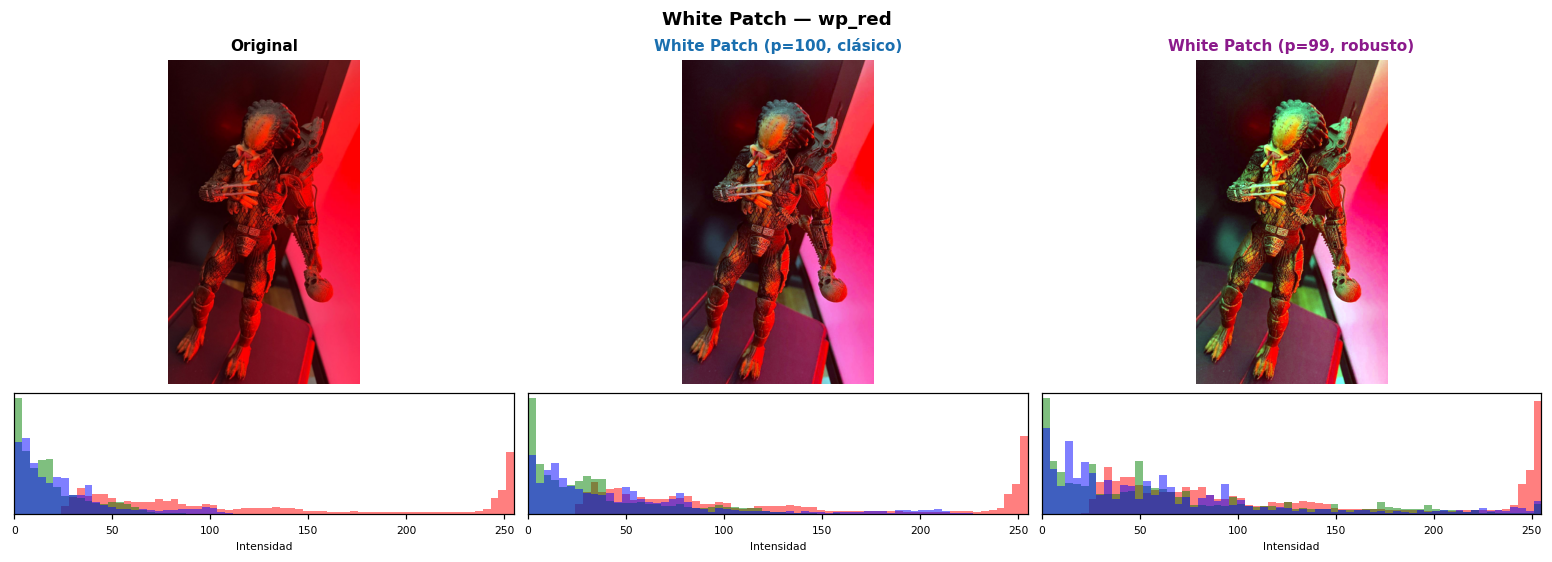


Imagen: wp_blue
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       255.0         1.000x       254.0         1.004x
Verde (G)      255.0         1.000x        86.0         2.965x
Rojo (R)       255.0         1.000x       117.0         2.179x


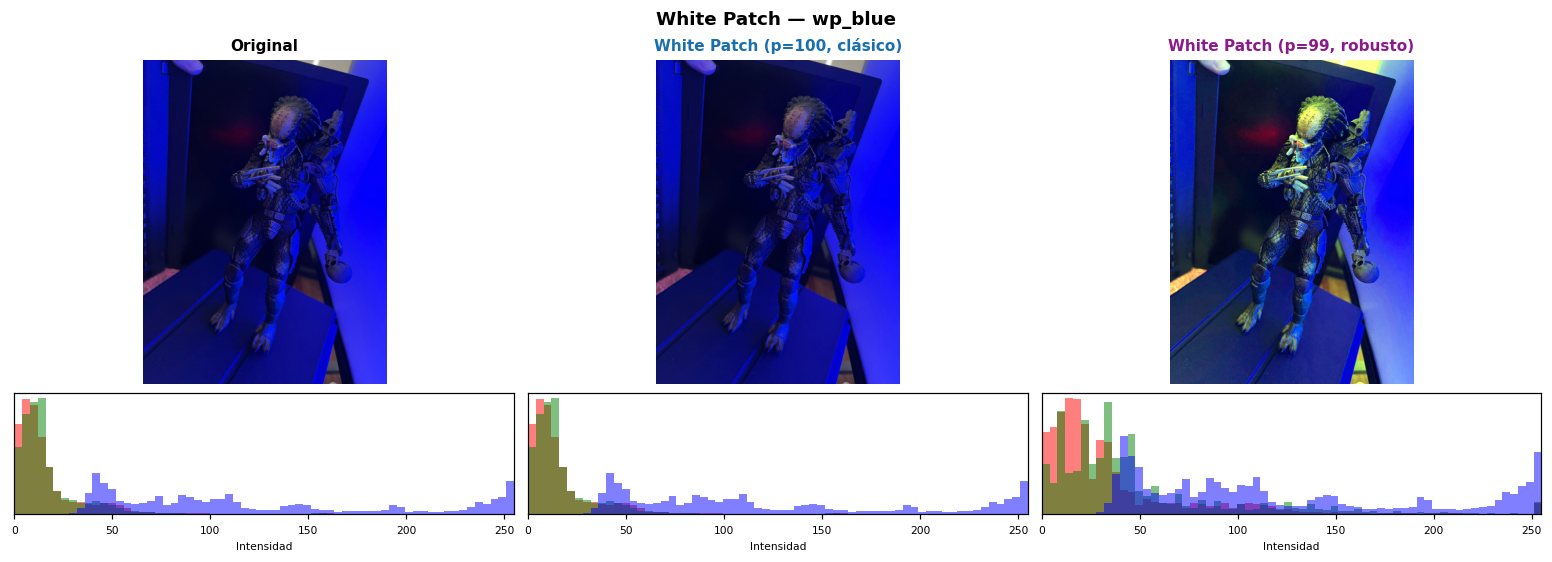


Imagen: wp_green2
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       172.0         1.483x        56.0         4.554x
Verde (G)      255.0         1.000x       255.0         1.000x
Rojo (R)       170.0         1.500x        70.0         3.643x


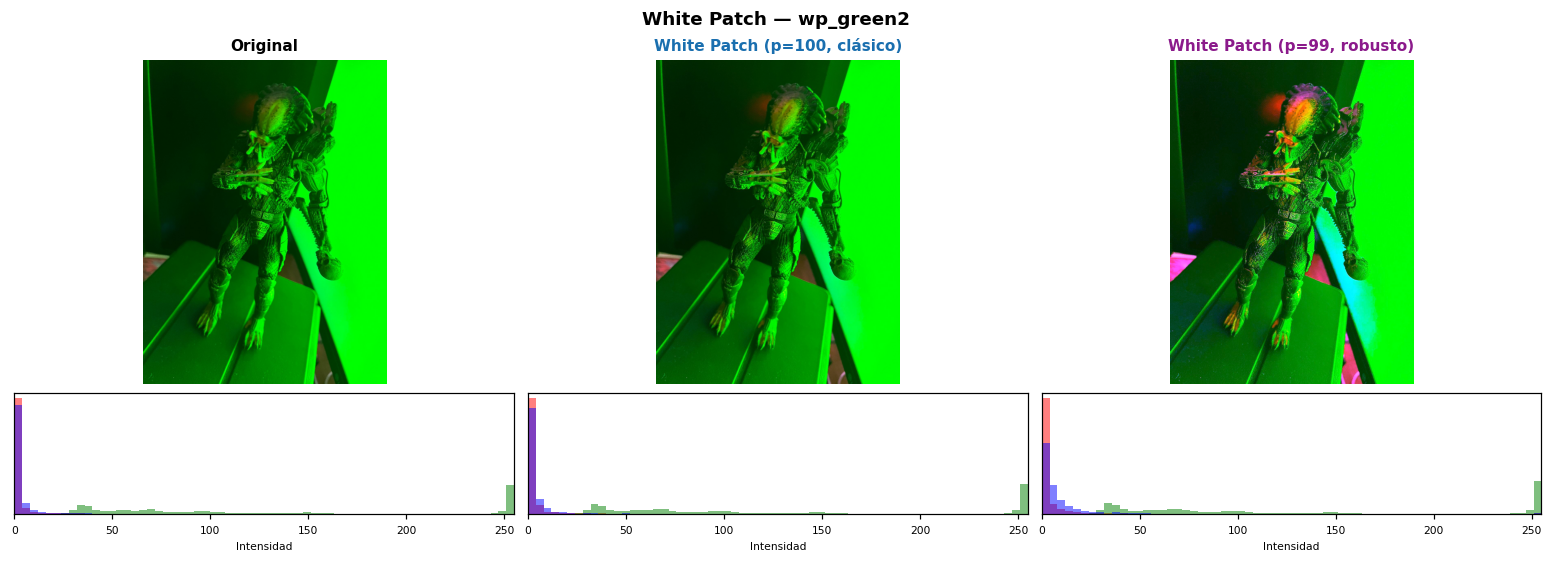


Imagen: wp_red2
Canal       Max abs   Ganancia abs        P99   Ganancia p99
------------------------------------------------------------
Azul (B)       203.0         1.256x       119.0         2.143x
Verde (G)      201.0         1.269x       119.0         2.143x
Rojo (R)       255.0         1.000x       255.0         1.000x


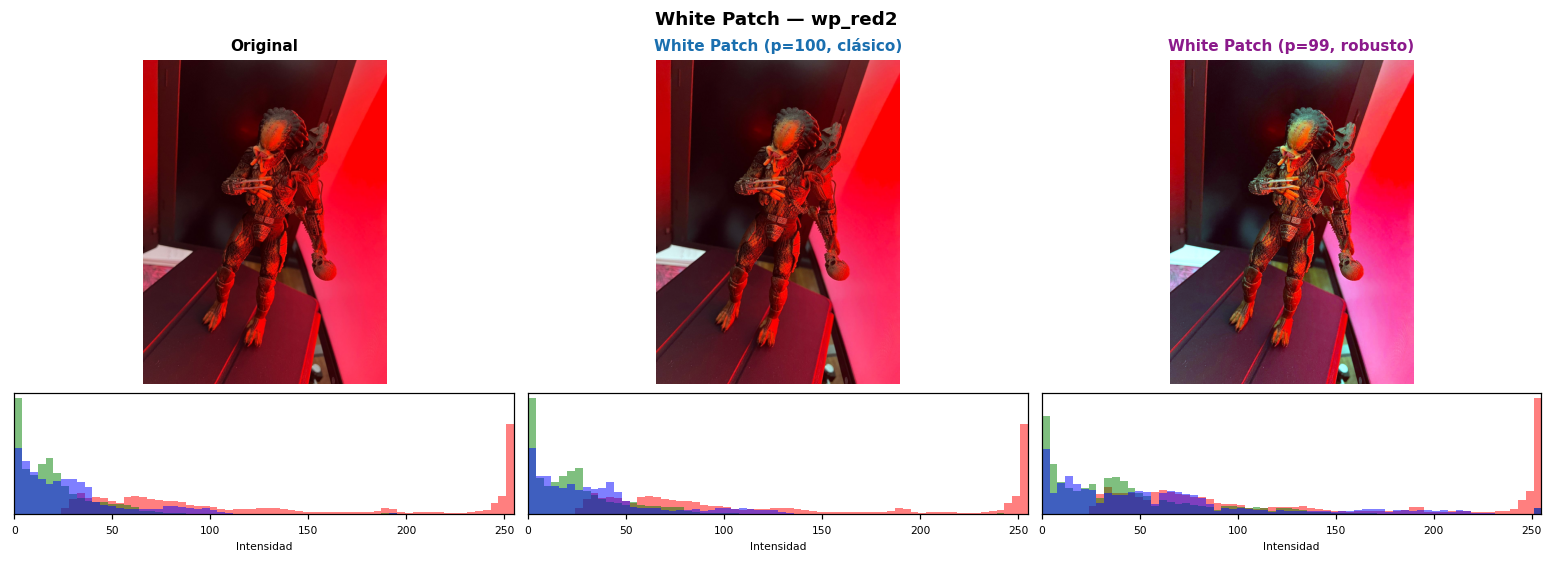

In [8]:
def show_results(name: str, original_bgr: np.ndarray):
    """Visualiza original, White Patch clásico y robusto con ganancias por canal."""
    wp_abs = white_patch(original_bgr, percentile=100.0)
    wp_rob = white_patch(original_bgr, percentile=99.0)

    # Convertir de BGR (openCV usa este) a RGB para matplotlib
    orig_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    abs_rgb  = cv2.cvtColor(wp_abs,       cv2.COLOR_BGR2RGB)
    rob_rgb  = cv2.cvtColor(wp_rob,       cv2.COLOR_BGR2RGB)

    #armo las figuras e histogramas
    fig = plt.figure(figsize=(14, 5), layout='constrained')
    gs  = gridspec.GridSpec(2, 3, height_ratios=[4, 1.5], figure=fig)

    titles = ['Original', 'White Patch (p=100, clásico)', 'White Patch (p=99, robusto)']
    imgs   = [orig_rgb, abs_rgb, rob_rgb]
    colors_title = ['black', '#1a6faf', '#8b1a8b']

    for col, (title, img, ctitle) in enumerate(zip(titles, imgs, colors_title)):
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(img)
        ax_img.set_title(title, color=ctitle, fontsize=10, fontweight='bold')
        ax_img.axis('off')

        # Histograma de cada canal
        ax_h = fig.add_subplot(gs[1, col])
        canal_colors = ['red', 'green', 'blue']
        for ch, cc in enumerate(canal_colors):
            ax_h.hist(img[:,:,ch].ravel(), bins=64, range=(0,255),
                      color=cc, alpha=0.5, density=True)
        ax_h.set_xlim(0, 255); ax_h.set_yticks([])
        ax_h.set_xlabel('Intensidad', fontsize=7)
        ax_h.tick_params(labelsize=7)

    # Tabla de ganancias
    print(f'\n{"="*50}')
    print(f'Imagen: {name}')
    print(f'{"Canal":<8} {"Max abs":>10} {"Ganancia abs":>14} {"P99":>10} {"Ganancia p99":>14}')
    print('-'*60)
    canal_nombres = ['Azul (B)', 'Verde (G)', 'Rojo (R)']
    for ch, cn in enumerate(canal_nombres):
        mabs = np.percentile(original_bgr[:,:,ch], 100)
        p99  = np.percentile(original_bgr[:,:,ch], 99)
        print(f'{cn:<10} {mabs:>9.1f} {255/mabs if mabs>0 else 0:>13.3f}x   {p99:>9.1f} {255/p99 if p99>0 else 0:>13.3f}x')

    fig.suptitle(f'White Patch — {name}', fontsize=12, fontweight='bold')
    plt.show()


for name, img_bgr in images_wp.items():
    show_results(name, img_bgr)

## 1.2 Resultados obtenidos y análisis de fallas

### Grupo 1 — imágenes `test_*` (casos limpios)

Estas tres funcionan exactamente como se espera. Las ganancias son moderadas
y la diferencia entre *abs* y *p99* es pequeña, lo que indica imágenes sin ruido significativo:

| Imagen | Canal dominante | Interpretación |
|---|---|---|
| `test_blue` | B = 200 | Iluminación fría, G y R suprimidos |
| `test_green` | G = 250 | Iluminación verdosa, casi saturado |
| `test_red` | R = 247 | Iluminación cálida/rojiza |

---

### Grupo 2 — imágenes `wp_*` (casos problemáticos)

#### `wp_blue` — falla por sobreexposición (diferencia grande pero max=255)
```
Azul (B)   Max abs: 255   Ganancia abs: 1.000x   P99: 254   Ganancia p99: 1.004x
Verde (G)  Max abs: 255   Ganancia abs: 1.000x   P99:  86   Ganancia p99: 2.965x
Rojo (R)   Max abs: 255   Ganancia abs: 1.000x   P99: 117   Ganancia p99: 2.179x
```

Los tres canales tienen máximo absoluto = 255, entonces el método clásico no aplica
ninguna corrección (ganancia 1.0 en todos). Sin embargo, el *p99* del verde es apenas
86 y el del rojo 117: el 99 % de los píxeles de esos canales están muy por debajo de 255.
Unos pocos píxeles saturados engañan al máximo absoluto, haciéndole creer que no hay
tinte cuando en realidad sí lo hay. **El método clásico falla completamente aquí.**
La variante p99 sí detecta el desbalance y aplica la corrección correspondiente.

#### `wp_green2` — falla por outliers en azul y rojo (diferencia grande, y max NI SIQUIERA es 255)
```
Azul (B)   Max abs: 172   Ganancia abs: 1.483x   P99:  56   Ganancia p99: 4.554x
Verde (G)  Max abs: 255   Ganancia abs: 1.000x   P99: 255   Ganancia p99: 1.000x
Rojo (R)   Max abs: 170   Ganancia abs: 1.500x   P99:  70   Ganancia p99: 3.643x
```

La diferencia entre *abs* y *p99* es enorme en B y R (172→56 y 170→70).
Un máximo absoluto casi el triple del percentil 99 solo puede explicarse por píxeles
aislados muy brillantes.
El método clásico calcula una ganancia de ~1.5×, cuando la corrección real necesaria
es ~4×. **El abs subestima fuertemente la amplificación necesaria.**

#### `wp_red` / `wp_red2` — canal rojo saturado con outliers en verde
```
# wp_red
Rojo (R)   Max abs: 255   Ganancia abs: 1.000x   P99: 255   Ganancia p99: 1.000x
Verde (G)  Max abs: 134   Ganancia abs: 1.903x   P99:  74   Ganancia p99: 3.446x
```

El rojo está saturado en ambas métricas (p99 = 255), por lo que no hay problema en
ese canal. Pero el verde muestra *abs* = 134 vs *p99* = 74, una diferencia que
delata la presencia de outliers. La ganancia estimada por el máximo absoluto (1.9×)
es casi la mitad de la real (3.4×): la corrección del verde quedará incompleta si
se usa el máximo absoluto.


---
**Parte 2:** 

## 2.1 Lectura con OpenCV en escala de grises

In [9]:
# Lectura con OpenCV en escala de grises
# cv2.IMREAD_GRAYSCALE carga directamente en un solo canal (H, W)
img1 = cv2.imread('img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2_tp.png', cv2.IMREAD_GRAYSCALE)

assert img1 is not None, 'No se pudo cargar img1_tp.png'
assert img2 is not None, 'No se pudo cargar img2_tp.png'

print('img1 — shape:', img1.shape, '| dtype:', img1.dtype,
      '| min:', img1.min(), '| max:', img1.max(), '| mean:', img1.mean().round(2))
print('img2 — shape:', img2.shape, '| dtype:', img2.dtype,
      '| min:', img2.min(), '| max:', img2.max(), '| mean:', img2.mean().round(2))

img1 — shape: (288, 287) | dtype: uint8 | min: 2 | max: 255 | mean: 154.81
img2 — shape: (288, 287) | dtype: uint8 | min: 2 | max: 255 | mean: 154.81


## 2.1 Visualización de las imágenes

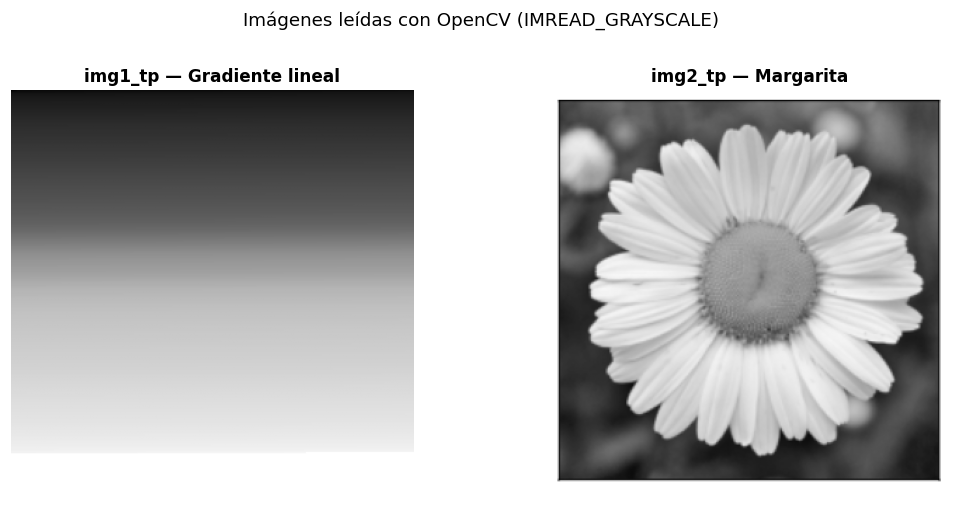

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp — Gradiente lineal', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp — Margarita', fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Imágenes leídas con OpenCV', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2.2 Elección del número de bins

Para imágenes uint8 (0–255) se pueden usar hasta 256 bins (uno por nivel).
Sin embargo, una cantidad menor de bins suaviza la distribución y facilita
la interpretación visual. Se comparan **32, 64 y 256 bins**:

- **64 bins** — equilibrio entre detalle y legibilidad ← **elección para el análisis**  


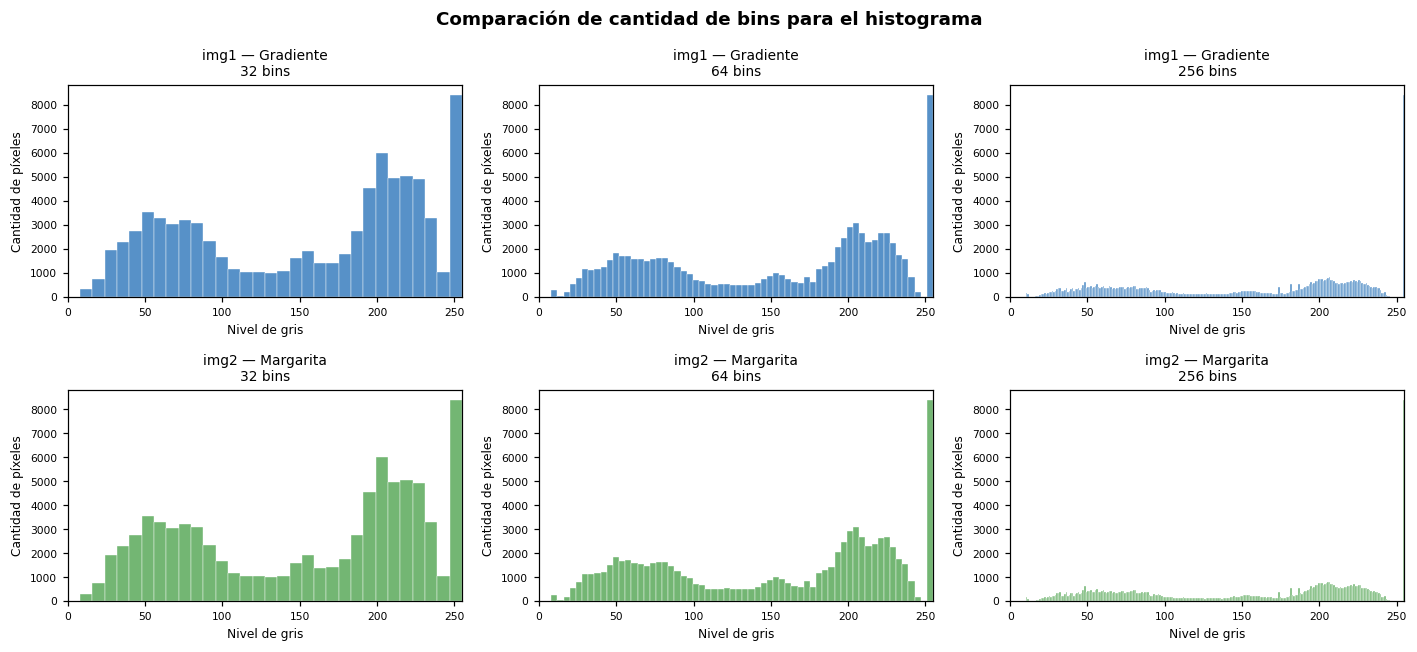

Elección: 64 bins — ofrece el mejor balance entre detalle y claridad visual.


In [11]:
bins_options = [32, 64, 256]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)

for col, n_bins in enumerate(bins_options):
    for row, (img, name, color) in enumerate([
            (img1, 'img1 — Gradiente', '#3a7ebf'),
            (img2, 'img2 — Margarita', '#5aaa5a')]):

        ax = axes[row, col]
        ax.hist(img.ravel(), bins=n_bins, range=(0, 255),
                color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
        ax.set_title(f'{name}\n{n_bins} bins', fontsize=9)
        ax.set_xlabel('Nivel de gris', fontsize=8)
        ax.set_ylabel('Cantidad de píxeles', fontsize=8)
        ax.set_xlim(0, 255)
        ax.tick_params(labelsize=7)

plt.suptitle('Comparación de cantidad de bins para el histograma', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Elección: 64 bins — ofrece el mejor balance entre detalle y claridad visual.')

## 2.2 Histogramas con 64 bins — comparación entre imágenes

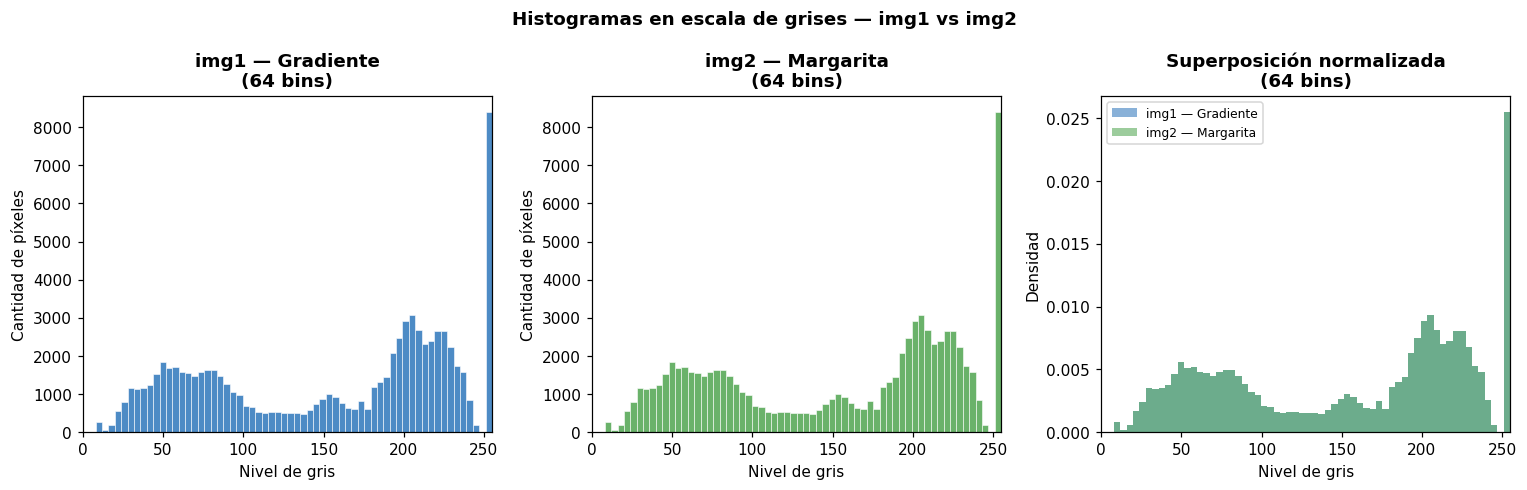

In [12]:
BINS = 64  # Elección final

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Histograma img1
axes[0].hist(img1.ravel(), bins=BINS, range=(0,255),
             color='#3a7ebf', edgecolor='white', linewidth=0.4, alpha=0.9)
axes[0].set_title(f'img1 — Gradiente\n({BINS} bins)', fontweight='bold')
axes[0].set_xlabel('Nivel de gris'); axes[0].set_ylabel('Cantidad de píxeles')
axes[0].set_xlim(0, 255)

# Histograma img2
axes[1].hist(img2.ravel(), bins=BINS, range=(0,255),
             color='#5aaa5a', edgecolor='white', linewidth=0.4, alpha=0.9)
axes[1].set_title(f'img2 — Margarita\n({BINS} bins)', fontweight='bold')
axes[1].set_xlabel('Nivel de gris'); axes[1].set_ylabel('Cantidad de píxeles')
axes[1].set_xlim(0, 255)

# Superposición
axes[2].hist(img1.ravel(), bins=BINS, range=(0,255),
             color='#3a7ebf', edgecolor='none', alpha=0.6, label='img1 — Gradiente', density=True)
axes[2].hist(img2.ravel(), bins=BINS, range=(0,255),
             color='#5aaa5a', edgecolor='none', alpha=0.6, label='img2 — Margarita', density=True)
axes[2].set_title(f'Superposición normalizada\n({BINS} bins)', fontweight='bold')
axes[2].set_xlabel('Nivel de gris'); axes[2].set_ylabel('Densidad')
axes[2].set_xlim(0, 255)
axes[2].legend(fontsize=8)

plt.suptitle('Histogramas en escala de grises — img1 vs img2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.2 Verificación cuantitativa: ¿son iguales los histogramas?

In [14]:
# Histogramas a resolución máxima (256 bins)
h1 = cv2.calcHist([img1], [0], None, [256], [0, 256]).ravel()
h2 = cv2.calcHist([img2], [0], None, [256], [0, 256]).ravel()

son_iguales = np.array_equal(h1, h2)
mae = np.abs(h1 - h2).mean()

print(f'¿Histogramas idénticos (256 bins)? → {son_iguales}')
print(f'Error absoluto medio entre histogramas: {mae:.4f}')
print()

# Estadísticas
print(f'{"Estadística":<20} {"img1":>12} {"img2":>12}')
print('-' * 46)
stats = [
    ('Media',    img1.mean(),                    img2.mean()),
    ('Desv. std',img1.std(),                     img2.std()),
    ('Mínimo',   float(img1.min()),              float(img2.min())),
    ('Máximo',   float(img1.max()),              float(img2.max())),
    ('Mediana',  float(np.median(img1)),         float(np.median(img2))),
    ('Q1 (25%)', float(np.percentile(img1,25)),  float(np.percentile(img2,25))),
    ('Q3 (75%)', float(np.percentile(img1,75)),  float(np.percentile(img2,75))),
]
for label, v1, v2 in stats:
    print(f'{label:<20} {v1:>12.2f} {v2:>12.2f}')

¿Histogramas idénticos (256 bins)? → True
Error absoluto medio entre histogramas: 0.0000

Estadística                  img1         img2
----------------------------------------------
Media                      154.81       154.81
Desv. std                   75.34        75.34
Mínimo                       2.00         2.00
Máximo                     255.00       255.00
Mediana                    182.00       182.00
Q1 (25%)                    78.00        78.00
Q3 (75%)                   219.00       219.00


## 2.2 Análisis y conclusiones

### ¿Qué se observa en los histogramas?

#### img1 — Gradiente lineal de negro a blanco

El histograma muestra una distribución **aproximadamente uniforme** a lo largo de todos
los niveles de gris (0–255). Esto es consistente con la naturaleza de la imagen:
cada fila de píxeles tiene un nivel de gris distinto que va incrementándose
progresivamente de arriba (negro) hacia abajo (blanco). Hay un pequeño pico en los
valores altos (cerca de 255) visible en la región blanca inferior.

#### img2 — Margarita

A pesar de ser una imagen completamente distinta, el histograma es **idéntico** al de img1.
Esto se puede verificar numéricamente: el error absoluto medio entre ambos histogramas
es **0.0000** (son exactamente iguales).

---

### El hallazgo central: mismas estadísticas, contenido completamente diferente

| Propiedad | img1 (Gradiente) | img2 (Margarita) |
|---|---|---|
| Media | 154.81 | 154.81 |
| Desv. std | 75.34 | 75.34 |
| Histograma | idéntico | idéntico |
| Contenido visual | gradiente suave | flor con bordes y texturas |

Dos imágenes perceptualmente **opuestas** tienen exactamente la misma distribución
de niveles de gris.

---

### ¿Sirve el histograma como feature para clasificación/detección?

**Respuesta: depende del problema, pero tiene limitaciones severas.**

#### Por qué el histograma puede ser útil
- Captura la **distribución global de intensidades**: imágenes nocturnas vs. diurnas,
  escenas nevadas vs. boscosas, documentos vs. fotografías.
- Es **invariante a traslaciones y rotaciones**: si la misma escena se traslada o rota,
  el histograma no cambia.
- Muy eficiente de calcular y de bajo costo computacional.

#### Por qué el histograma solo NO alcanza

> **El histograma descarta completamente la información espacial.**

El ejemplo de este TP lo demuestra perfectamente: img1 (un gradiente sin estructura)
e img2 (una flor con bordes, texturas, formas complejas) tienen **exactamente el mismo
histograma**. Un modelo entrenado únicamente con histogramas como features **no podría
distinguirlas**.

#### Conclusión

El histograma es útil como **feature auxiliar o complementario**, pero nunca como
feature único para clasificación/detección de objetos.